# Rede Alimenta IA: análise exploratória e resultados do Checkpoint 1

Este notebook é a **narrativa visual** do CP1. Toda a lógica está nos módulos de `src/` e aqui só lemos os resultados:

| Etapa | Comando | Saída |
|---|---|---|
| Curadoria IPVS 2022 (SEADE) | `python -m src.data.curadoria_ipvs` | `data/reference/` |
| Dataset simulado | `python -m src.data.gerar_dataset` | `data/processed/` |
| Modelos 1 e 2 | `python -m src.models.treinar` | `models/`, `reports/metricas_modelos.json` |
| NLP + guardrail | `python -m src.models.avaliar_nlp` | `reports/avaliacao_nlp.json` |

Regras de negócio: `docs/regras-de-negocio.md` · Dicionário: `docs/dicionario-de-dados.md` · STRIDE: `docs/stride/matriz-stride.md`

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))
PROC, REF, REP = RAIZ / "data/processed", RAIZ / "data/reference", RAIZ / "reports"

# Paleta de referência validada (skill de dataviz): azul = série 1 / sequencial, laranja = série 2.
AZUL, LARANJA = "#2a78d6", "#eb6834"
SEQ_IPVS = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281", "#0d366b"]  # grupos 1..6 (ordinal)
MAPA_SEQ = LinearSegmentedColormap.from_list("seq_azul", ["#cde2fb", "#6da7ec", "#256abf", "#0d366b"])
TINTA, TINTA2, MUDO, GRADE, BASE, SUPERFICIE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE, "savefig.facecolor": SUPERFICIE,
    "axes.edgecolor": BASE, "axes.labelcolor": TINTA2, "text.color": TINTA,
    "xtick.color": MUDO, "ytick.color": MUDO, "xtick.labelcolor": TINTA2, "ytick.labelcolor": TINTA2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRADE, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "figure.dpi": 110, "legend.frameon": False,
})

def barras_h(ax, rotulos, valores, fmt="{:.0%}", cor=AZUL):
    """Barras horizontais finas com rótulo direto no fim de cada barra."""
    y = np.arange(len(valores))
    ax.barh(y, valores, height=0.62, color=cor)
    ax.set_yticks(y, rotulos)
    ax.grid(axis="y", visible=False)
    for yi, v in zip(y, valores):
        ax.text(v, yi, "  " + fmt.format(v), va="center", fontsize=9, color=TINTA2)
    ax.set_xlim(0, max(valores) * 1.18)

lotes = pd.read_csv(PROC / "lotes.csv", parse_dates=["ts_cadastro"], low_memory=False)
validos = lotes[lotes["status_final"] != "BLOQUEADO"].copy()
validos["descartado"] = validos["descartado"].astype(bool)
entregues = validos[validos["status_final"] == "ENTREGUE"]
doadores, ongs = pd.read_csv(PROC / "doadores.csv"), pd.read_csv(PROC / "ongs.csv")
setores = pd.read_csv(REF / "setores_rmsp.csv", dtype={"cd_setor": str})
setores = setores[setores["ipvs_grupo"].notna()]
regioes = pd.read_csv(REF / "regioes.csv")

## Os números do ano simulado (set/2025 a ago/2026)

In [2]:
kpis = {
    "Lotes cadastrados": f"{len(lotes):,}".replace(",", "."),
    "Bloqueados no cadastro (validade)": f"{(lotes['status_final'] == 'BLOQUEADO').mean():.1%}",
    "Taxa de descarte (lotes válidos)": f"{validos['descartado'].mean():.1%}",
    "Toneladas salvas": f"{entregues['peso_kg'].sum() / 1000:,.0f} t".replace(",", "."),
    "Refeições geradas": f"{entregues['refeicoes'].sum():,.0f}".replace(",", "."),
    "Tempo mediano de match": f"{validos['minutos_ate_match'].median():.0f} min",
    "Lotes com entregador pago (caixa)": f"{validos['acionou_pago'].fillna(False).astype(bool).mean():.1%}",
}
display(Markdown("| Indicador | Valor |\n|---|---|\n" + "\n".join(f"| {k} | **{v}** |" for k, v in kpis.items())))

| Indicador | Valor |
|---|---|
| Lotes cadastrados | **25.939** |
| Bloqueados no cadastro (validade) | **4.4%** |
| Taxa de descarte (lotes válidos) | **11.4%** |
| Toneladas salvas | **416 t** |
| Refeições geradas | **1.096.723** |
| Tempo mediano de match | **22 min** |
| Lotes com entregador pago (caixa) | **1.7%** |

## 1. O problema no mapa: a comida sobra onde a fome não está

À esquerda, os **36.847 setores censitários reais** do recorte, coloridos pelo **IPVS 2022 (SEADE)**. À direita, onde a simulação posiciona **doadores PJ** (comércio, concentrado em áreas de baixa vulnerabilidade) e **ONGs** (concentradas nas áreas mais vulneráveis). É esse descompasso que a plataforma resolve.

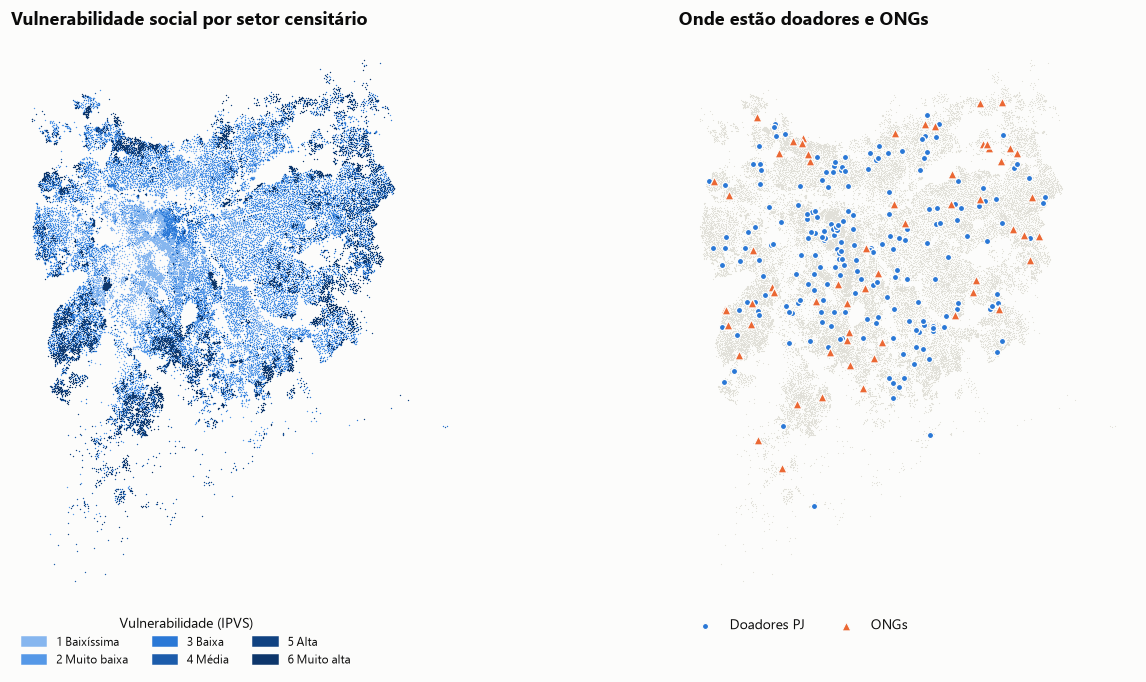

**85%** dos doadores PJ estão em setores de vulnerabilidade baixíssima/muito baixa · **77%** das ONGs estão em setores de vulnerabilidade alta/muito alta.

In [3]:
aspecto = 1 / np.cos(np.radians(-23.6))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6.3))
for g in range(1, 7):
    s = setores[setores["ipvs_grupo"] == g]
    ax1.scatter(s["lon"], s["lat"], s=0.8, color=SEQ_IPVS[g - 1], linewidths=0, rasterized=True)
nomes = ["1 Baixíssima", "2 Muito baixa", "3 Baixa", "4 Média", "5 Alta", "6 Muito alta"]
ax1.legend([Patch(color=c) for c in SEQ_IPVS], nomes, title="Vulnerabilidade (IPVS)", loc="upper left", bbox_to_anchor=(0.0, 0.0), ncol=3, fontsize=8, title_fontsize=9)
ax1.set_title("Vulnerabilidade social por setor censitário")

ax2.scatter(setores["lon"], setores["lat"], s=0.6, color=GRADE, linewidths=0, rasterized=True)
pj = doadores[doadores["tipo_doador"] == "PJ"]
ax2.scatter(pj["lon"], pj["lat"], s=16, color=AZUL, edgecolors=SUPERFICIE, linewidths=0.8, label="Doadores PJ")
ax2.scatter(ongs["lon"], ongs["lat"], s=34, marker="^", color=LARANJA, edgecolors=SUPERFICIE, linewidths=0.8, label="ONGs")
ax2.legend(loc="upper left", bbox_to_anchor=(0.0, 0.0), ncol=2, fontsize=9)
ax2.set_title("Onde estão doadores e ONGs")
for ax in (ax1, ax2):
    ax.set_aspect(aspecto); ax.axis("off")
plt.tight_layout(); plt.show()

pj_rico = pj["ipvs_grupo"].isin([1, 2]).mean()
ong_vuln = ongs["ipvs_grupo"].isin([5, 6]).mean()
display(Markdown(f"**{pj_rico:.0%}** dos doadores PJ estão em setores de vulnerabilidade baixíssima/muito baixa · "
                 f"**{ong_vuln:.0%}** das ONGs estão em setores de vulnerabilidade alta/muito alta."))

## 2. Quando as doações acontecem

Os horários seguem **tendências por segmento, não janelas fixas** (regras 8.1). O pico das 22 h dos restaurantes é o cenário mais difícil: comida pronta, à noite, com pouca frota.

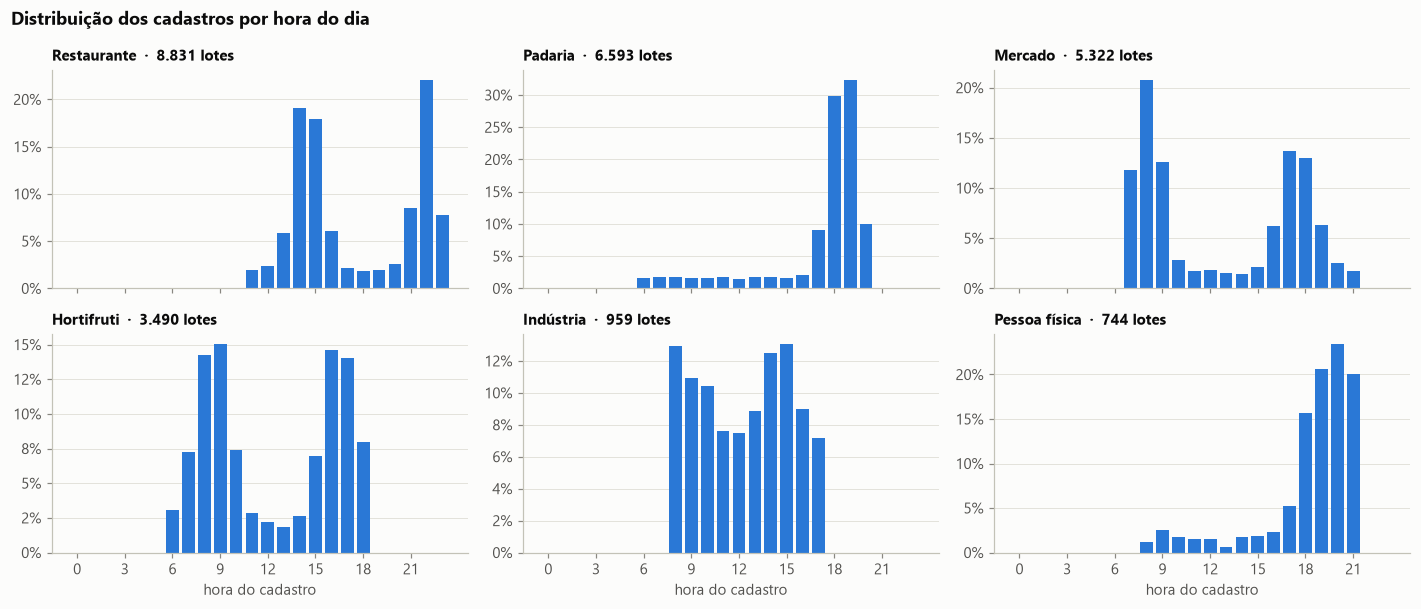

In [4]:
segmentos = ["restaurante", "padaria", "mercado", "hortifruti", "industria", "pf"]
titulos = {"restaurante": "Restaurante", "padaria": "Padaria", "mercado": "Mercado", "hortifruti": "Hortifruti",
           "industria": "Indústria", "pf": "Pessoa física"}
fig, eixos = plt.subplots(2, 3, figsize=(13, 5.6), sharex=True)
for ax, seg in zip(eixos.flat, segmentos):
    horas = lotes.loc[lotes["segmento"] == seg, "ts_cadastro"].dt.hour
    dist = horas.value_counts(normalize=True).reindex(range(24), fill_value=0)
    ax.bar(dist.index, dist.values, width=0.8, color=AZUL)
    ax.set_title(f"{titulos[seg]}  ·  {len(horas):,} lotes".replace(",", "."), fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.grid(axis="x", visible=False); ax.set_xticks(range(0, 24, 3))
for ax in eixos[1]:
    ax.set_xlabel("hora do cadastro")
fig.suptitle("Distribuição dos cadastros por hora do dia", x=0.01, ha="left", fontweight="bold")
plt.tight_layout(); plt.show()

## 3. Onde a comida é perdida

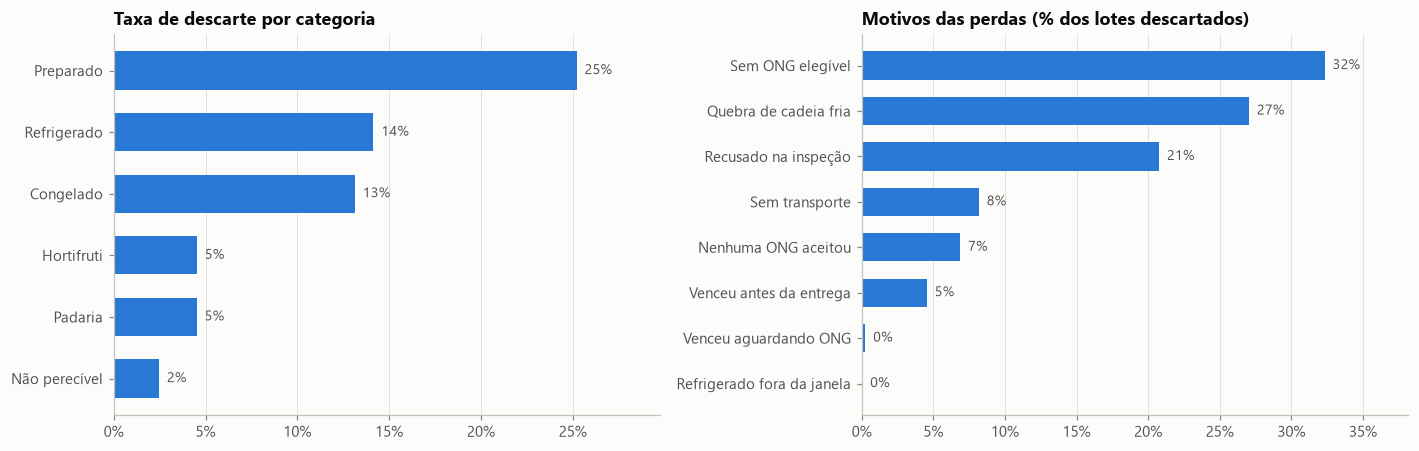

In [5]:
nomes_cat = {"preparado": "Preparado", "refrigerado": "Refrigerado", "congelado": "Congelado",
             "padaria": "Padaria", "hortifruti": "Hortifruti", "nao_perecivel": "Não perecível"}
nomes_mot = {"SEM_ONG_ELEGIVEL": "Sem ONG elegível", "QUEBRA_CADEIA_FRIA": "Quebra de cadeia fria",
             "RECUSADO_NA_INSPECAO": "Recusado na inspeção", "SEM_TRANSPORTE": "Sem transporte",
             "NENHUMA_ONG_ACEITOU": "Nenhuma ONG aceitou", "VENCEU_ANTES_DA_ENTREGA": "Venceu antes da entrega",
             "VENCEU_AGUARDANDO_ONG": "Venceu aguardando ONG", "REFRIGERADO_FORA_DA_JANELA": "Refrigerado fora da janela"}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
taxa = validos.groupby("categoria")["descartado"].mean().sort_values()
barras_h(ax1, [nomes_cat[c] for c in taxa.index], taxa.values)
ax1.set_title("Taxa de descarte por categoria"); ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
mot = validos.loc[validos["descartado"], "motivo_descarte"].value_counts(normalize=True).sort_values()
barras_h(ax2, [nomes_mot.get(m, m) for m in mot.index], mot.values)
ax2.set_title("Motivos das perdas (% dos lotes descartados)"); ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.tight_layout(); plt.show()

### 3.1 A rota expressa (comida pronta fora da geladeira)

Na primeira versão da simulação, **88% desses lotes eram perdidos, e 100% entre 20 h e 24 h**: nenhuma ONG serve refeição de madrugada. Isso revelou duas **regras de negócio que faltavam**: o **turno noturno** (coletivos que atendem a população em situação de rua) e a **orientação de refrigeração** (regras 7.5). O gráfico mostra o resultado *com* as regras novas.

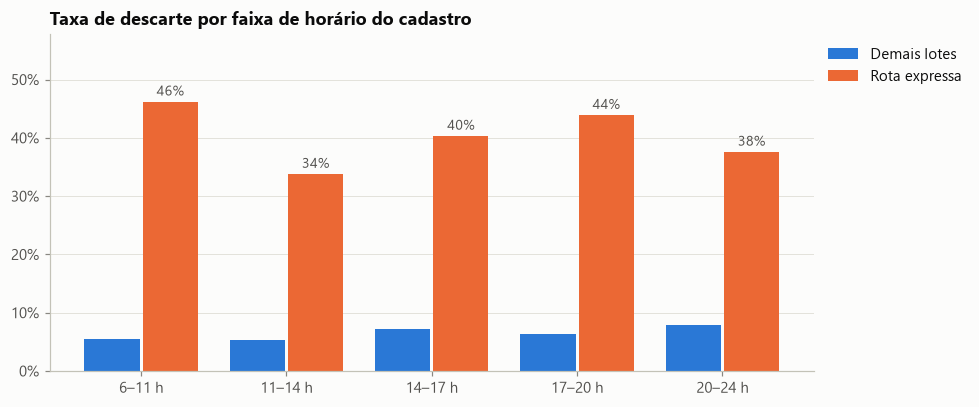

Rota expressa: **70%** dos lotes receberam orientação de refrigeração e **45%** foram refrigerados pelo doador e voltaram ao fluxo normal. Taxa de descarte dos refrigerados após orientação: **11%**.

In [6]:
faixas = pd.cut(validos["hora"], [5, 11, 14, 17, 20, 24], labels=["6–11 h", "11–14 h", "14–17 h", "17–20 h", "20–24 h"], right=False)
tab = validos.groupby([faixas, "rota_expressa"], observed=True)["descartado"].mean().unstack()
x = np.arange(len(tab)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 3.8))
b1 = ax.bar(x - w / 2 - 0.01, tab[False], w, color=AZUL, label="Demais lotes")
b2 = ax.bar(x + w / 2 + 0.01, tab[True], w, color=LARANJA, label="Rota expressa")
ax.bar_label(b2, labels=[f"{v:.0%}" for v in tab[True]], padding=2, fontsize=9, color=TINTA2)
ax.set_xticks(x, tab.index); ax.grid(axis="x", visible=False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("Taxa de descarte por faixa de horário do cadastro"); ax.set_ylim(0, max(tab[True]) * 1.25)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout(); plt.show()
exp = validos[validos["rota_expressa"]]
display(Markdown(f"Rota expressa: **{exp['orientado_refrigerar'].mean():.0%}** dos lotes receberam orientação de refrigeração e "
                 f"**{exp['refrigerado_apos_orientacao'].mean():.0%}** foram refrigerados pelo doador e voltaram ao fluxo normal."
                 f" Taxa de descarte dos refrigerados após orientação: **{exp.loc[exp['refrigerado_apos_orientacao'].astype(bool), 'descartado'].mean():.0%}**."))

## 4. Impacto social: para onde vai a comida

**Origem** = região do doador · **destino** = região da ONG que recebeu. O saldo positivo nas regiões periféricas é o efeito do **ranking com peso de vulnerabilidade** (regras 6.1).

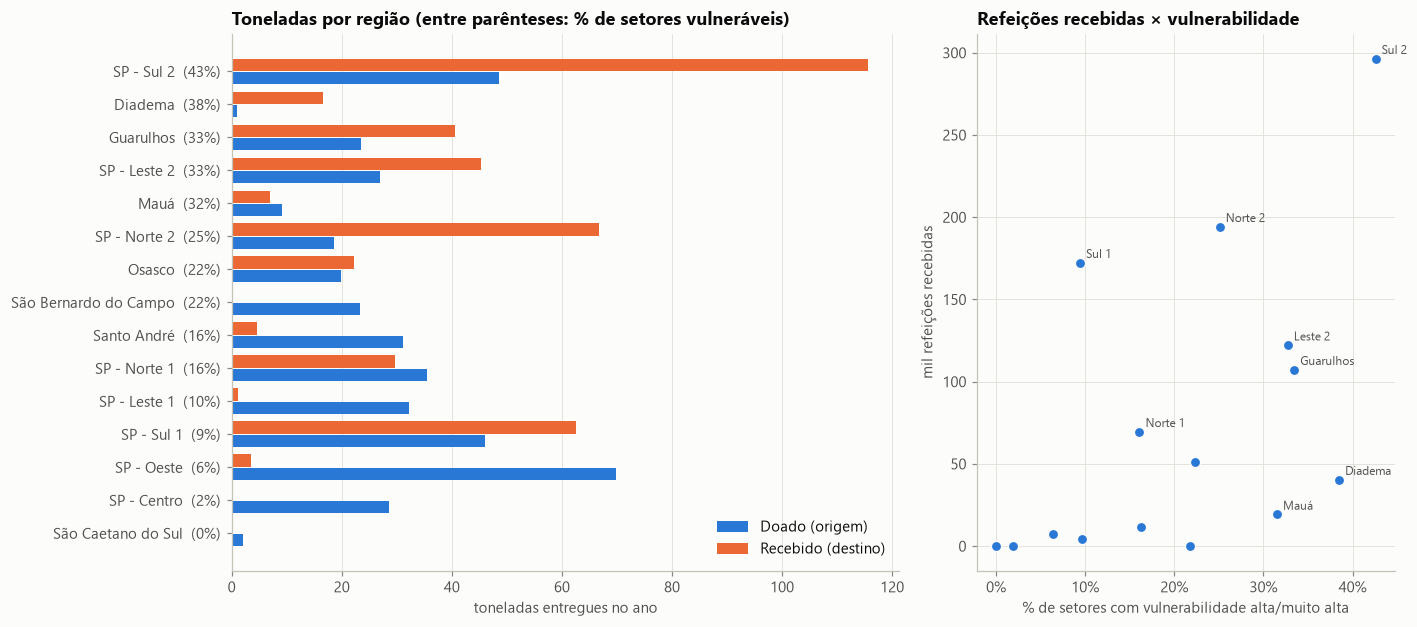

Correlação entre vulnerabilidade da região e refeições recebidas: **+0.53**.

In [7]:
ent = entregues.merge(ongs[["ong_id", "regiao"]].rename(columns={"regiao": "regiao_ong"}), on="ong_id")
origem = ent.groupby("regiao")["peso_kg"].sum() / 1000
destino = ent.groupby("regiao_ong")["peso_kg"].sum() / 1000
tab = pd.DataFrame({"origem": origem, "destino": destino}).fillna(0)
tab = tab.join(regioes.set_index("regiao")["pct_vulneravel"]).sort_values("pct_vulneravel")
y = np.arange(len(tab)); h = 0.38
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.8), gridspec_kw={"width_ratios": [1.6, 1]})
ax1.barh(y - h / 2 - 0.01, tab["origem"], h, color=AZUL, label="Doado (origem)")
ax1.barh(y + h / 2 + 0.01, tab["destino"], h, color=LARANJA, label="Recebido (destino)")
ax1.set_yticks(y, [f"{r}  ({p:.0%})" for r, p in zip(tab.index, tab["pct_vulneravel"])])
ax1.set_xlabel("toneladas entregues no ano"); ax1.grid(axis="y", visible=False)
ax1.set_title("Toneladas por região (entre parênteses: % de setores vulneráveis)"); ax1.legend(loc="lower right")

ref = ent.groupby("regiao_ong")["refeicoes"].sum()
pts = regioes.set_index("regiao").join(ref.rename("refeicoes")).fillna(0)
ax2.scatter(pts["pct_vulneravel"], pts["refeicoes"] / 1000, s=46, color=AZUL, edgecolors=SUPERFICIE, linewidths=1)
for r, row in pts.iterrows():
    if row["refeicoes"] >= pts["refeicoes"].quantile(0.6) or row["pct_vulneravel"] >= 0.3:
        ax2.annotate(r.replace("SP - ", ""), (row["pct_vulneravel"], row["refeicoes"] / 1000), fontsize=8,
                     color=TINTA2, xytext=(4, 3), textcoords="offset points")
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax2.set_xlabel("% de setores com vulnerabilidade alta/muito alta"); ax2.set_ylabel("mil refeições recebidas")
ax2.set_title("Refeições recebidas × vulnerabilidade")
plt.tight_layout(); plt.show()
corr = pts["pct_vulneravel"].corr(pts["refeicoes"])
display(Markdown(f"Correlação entre vulnerabilidade da região e refeições recebidas: **{corr:+.2f}**."))

## 5. Modelos de IA (teste: jun–ago/2026, período nunca visto no treino)

- **Modelo 1 (prioridade):** empata com a regra (é o **teto teórico**, porque o rótulo é regra + ~9% de discordância humana). O que importa: **nenhum lote CRÍTICO foi classificado como MÉDIA ou BAIXA**.
- **Modelo 2 (descarte):** supera a heurística atual em PR-AUC e opera com **recall ≥ 85%**, porque perder comida custa mais que acionar o caixa (regras 8).

| Modelo 1 (teste) | Acurácia | Macro-F1 | Recall CRÍTICA |
|---|---|---|---|
| Ingênuo (classe mais comum) | 30.3% | 11.6% | 0% |
| Regra determinística | 92.5% | 92.6% | 95.2% |
| **random_forest** | **92.3%** | **92.4%** | **95.0%** |

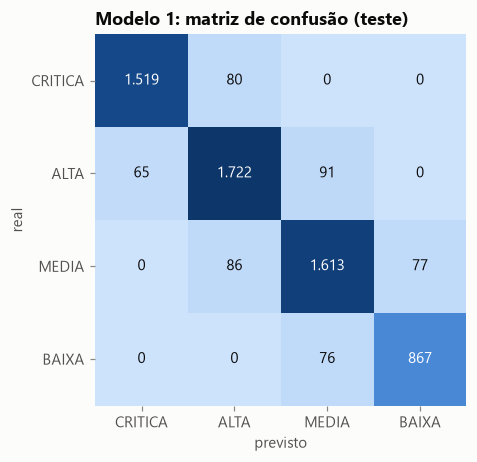

In [8]:
met = json.loads((REP / "metricas_modelos.json").read_text(encoding="utf-8"))
m1, m2 = met["modelo_1_prioridade"]["teste"], met["modelo_2_descarte"]["teste"]
display(Markdown(
    "| Modelo 1 (teste) | Acurácia | Macro-F1 | Recall CRÍTICA |\n|---|---|---|---|\n"
    f"| Ingênuo (classe mais comum) | {m1['ingenuo_no_teste']['acuracia']:.1%} | {m1['ingenuo_no_teste']['f1_macro']:.1%} | {m1['ingenuo_no_teste']['recall_critica']:.0%} |\n"
    f"| Regra determinística | {m1['regra_no_teste']['acuracia']:.1%} | {m1['regra_no_teste']['f1_macro']:.1%} | {m1['regra_no_teste']['recall_critica']:.1%} |\n"
    f"| **{m1['modelo']}** | **{m1['acuracia']:.1%}** | **{m1['f1_macro']:.1%}** | **{m1['recall_critica']:.1%}** |"))

cm = np.array(m1["matriz_confusao"]["valores"]); ordem = m1["matriz_confusao"]["ordem"]
fig, ax = plt.subplots(figsize=(5.2, 4.3))
ax.imshow(cm, cmap=MAPA_SEQ); ax.grid(False)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{cm[i, j]:,}".replace(",", "."), ha="center", va="center", fontsize=10,
                color="white" if cm[i, j] > cm.max() * 0.45 else TINTA)
ax.set_xticks(range(4), ordem); ax.set_yticks(range(4), ordem)
ax.set_xlabel("previsto"); ax.set_ylabel("real"); ax.set_title("Modelo 1: matriz de confusão (teste)")
for s in ax.spines.values(): s.set_visible(False)
plt.tight_layout(); plt.show()

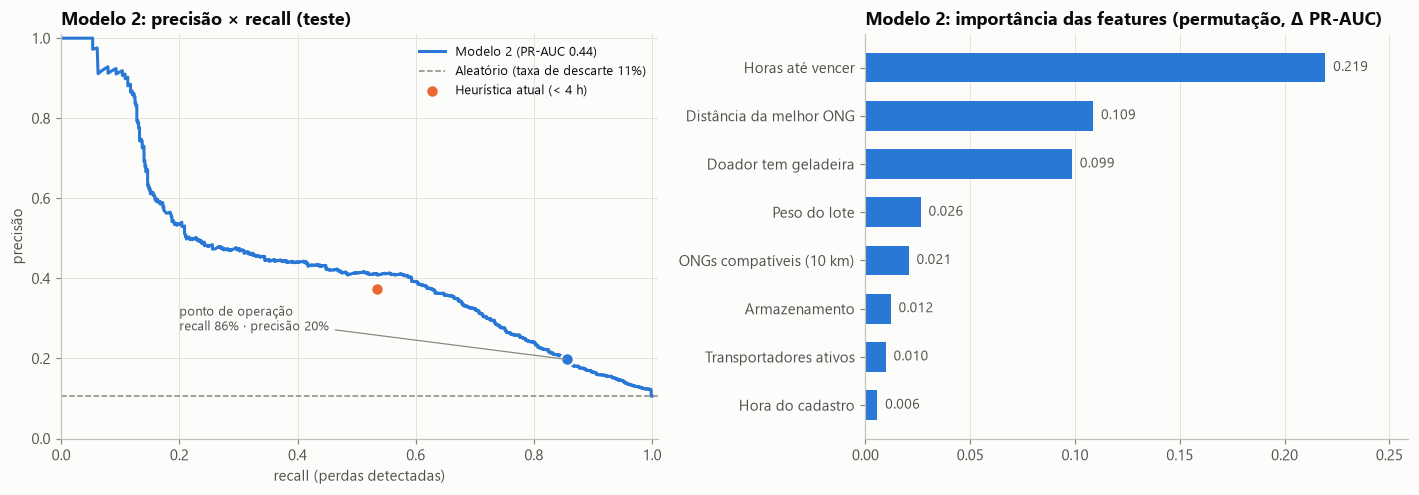

Modelo carregado com integridade verificada: `modelo_descarte.joblib` · SHA-256 `39142f87ca1808a4…` · limiar 0.273

In [9]:
from sklearn.metrics import precision_recall_curve
from src.models import features as F
from src.models.artefatos import carregar_modelo  # verifica o SHA-256 antes de desserializar

modelo_m1, _ = carregar_modelo("modelo_prioridade")
modelo_m2, meta_m2 = carregar_modelo("modelo_descarte")
_, _, teste = F.split_temporal(F.carregar_lotes_validos())
teste = teste.assign(prioridade=modelo_m1.predict(teste[F.M1_CATEGORICAS + F.M1_NUMERICAS + F.M1_BOOLEANAS]))
proba = modelo_m2.predict_proba(teste[F.M2_CATEGORICAS + F.M2_NUMERICAS + F.M2_BOOLEANAS])[:, 1]
prec, rec, _ = precision_recall_curve(teste["descartado"], proba)

heur = m2["heuristica_v0_no_teste"]; prevalencia = m2["taxa_descarte_teste"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1.1, 1]})
ax1.plot(rec, prec, color=AZUL, linewidth=2, label=f"Modelo 2 (PR-AUC {m2['pr_auc']:.2f})")
ax1.axhline(prevalencia, color=MUDO, linewidth=1, linestyle="--", label=f"Aleatório (taxa de descarte {prevalencia:.0%})")
ax1.scatter([heur["recall"]], [heur["precisao"]], s=70, color=LARANJA, edgecolors=SUPERFICIE, linewidths=1.5, zorder=3,
            label=f"Heurística atual (< 4 h)")
ax1.scatter([m2["recall"]], [m2["precisao"]], s=70, color=AZUL, edgecolors=SUPERFICIE, linewidths=1.5, zorder=3)
ax1.annotate(f"ponto de operação\nrecall {m2['recall']:.0%} · precisão {m2['precisao']:.0%}", (m2["recall"], m2["precisao"]),
             xytext=(0.20, 0.27), textcoords="data", fontsize=8.5, color=TINTA2,
             arrowprops=dict(arrowstyle="-", color=MUDO, lw=0.8))
ax1.set_xlabel("recall (perdas detectadas)"); ax1.set_ylabel("precisão")
ax1.set_xlim(0, 1.01); ax1.set_ylim(0, 1.01); ax1.legend(loc="upper right", fontsize=8.5)
ax1.set_title("Modelo 2: precisão × recall (teste)")

nomes_feat = {"horas_restantes": "Horas até vencer", "dist_ong_top_km": "Distância da melhor ONG",
              "doador_tem_refrigeracao": "Doador tem geladeira", "peso_kg": "Peso do lote",
              "n_ongs_compativeis_10km": "ONGs compatíveis (10 km)", "armazenamento": "Armazenamento",
              "n_transportadores_ativos_raio": "Transportadores ativos", "hora": "Hora do cadastro",
              "categoria": "Categoria", "regiao": "Região"}
imp = pd.Series(met["modelo_2_descarte"]["importancia_permutacao"]).head(8).sort_values()
barras_h(ax2, [nomes_feat.get(k, k) for k in imp.index], imp.values, fmt="{:.3f}")
ax2.set_title("Modelo 2: importância das features (permutação, Δ PR-AUC)")
plt.tight_layout(); plt.show()
display(Markdown(f"Modelo carregado com integridade verificada: `{meta_m2['artefato']}` · SHA-256 `{meta_m2['sha256_artefato'][:16]}…` · limiar {meta_m2['limiar']:.3f}"))

## 6. NLP de texto livre e guardrail de entrada

Primeira versão: zero-shot por NLI. **Medimos, não funcionou (49%) e trocamos** por similaridade de embeddings com exemplos escritos à mão, avaliada na **mesma amostra de teste**.

| Classificador (teste, 300 textos) | Categoria | Armazenamento (cadeia fria) | Tempo por texto |
|---|---|---|---|
| Baseline zero-shot NLI (`mDeBERTa-v3-base-mnli-xnli`) | 48.7% | 55.3% | 3.34 s |
| **Similaridade + exemplos** (`paraphrase-multilingual-MiniLM-L12-v2`) | **76.0%** | **79.3%** | **4.6 ms** |

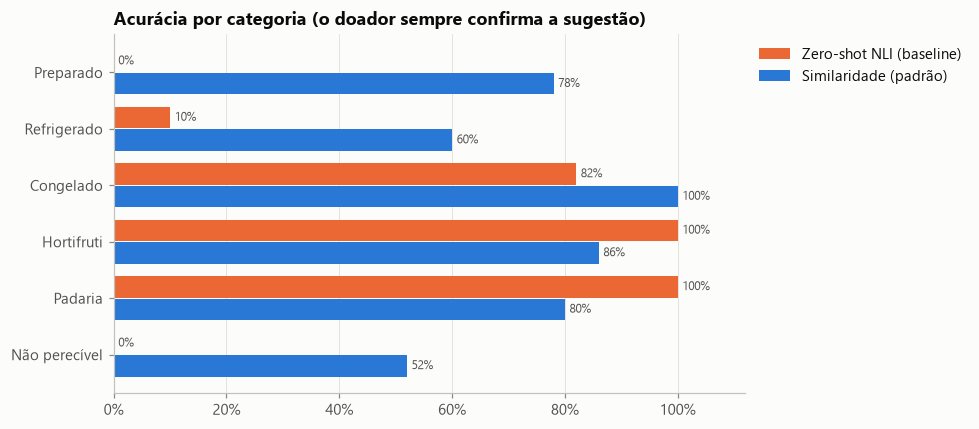

> Conjunto independente: **pendente** (ver `tests/dados/LEIA-ME_avaliacao_independente.md`).

| Guardrail | v1 | v2 |
|---|---|---|
| Payloads do dataset | 378/378 | 378/378 |
| Falsos positivos no dataset | 0/25561 | 0/25561 |
| Inéditos A (usados na mitigação) | 2/10 | 10/10 |
| Inéditos B (reservado) | 3/10 | 4/10 |
| Benignos com cara de ataque (falso positivo) | 1/10 | 0/10 |

In [10]:
nlp = json.loads((REP / "avaliacao_nlp.json").read_text(encoding="utf-8"))
pad, base, g = nlp["classificador_padrao"], nlp["baseline_nli"], nlp["guardrail"]
tp, tb = pad["teste_dataset"], base["teste_dataset"]
display(Markdown(
    "| Classificador (teste, 300 textos) | Categoria | Armazenamento (cadeia fria) | Tempo por texto |\n|---|---|---|---|\n"
    f"| Baseline zero-shot NLI (`{base['modelo'].split('/')[-1]}`) | {tb['acuracia_categoria']:.1%} | {tb['acuracia_armazenamento_cadeia_fria']:.1%} | {tb['segundos_por_texto']:.2f} s |\n"
    f"| **Similaridade + exemplos** (`{pad['modelo'].split('/')[-1]}`) | **{tp['acuracia_categoria']:.1%}** | **{tp['acuracia_armazenamento_cadeia_fria']:.1%}** | **{tp['segundos_por_texto'] * 1000:.1f} ms** |"))
cats = ORDEM_CAT = ["preparado", "refrigerado", "congelado", "hortifruti", "padaria", "nao_perecivel"]
y = np.arange(len(cats)); h = 0.38
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.barh(y - h / 2 - 0.01, [tb["acuracia_por_categoria"][c] for c in cats], h, color=LARANJA, label="Zero-shot NLI (baseline)")
b2 = ax.barh(y + h / 2 + 0.01, [tp["acuracia_por_categoria"][c] for c in cats], h, color=AZUL, label="Similaridade (padrão)")
for b in (b1, b2):
    ax.bar_label(b, labels=[f"{v:.0%}" for v in b.datavalues], padding=3, fontsize=8, color=TINTA2)
ax.set_yticks(y, [nomes_cat[c] for c in cats]); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
ax.set_xlim(0, 1.12); ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("Acurácia por categoria (o doador sempre confirma a sugestão)"); ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout(); plt.show()
indep = pad.get("independente")
display(Markdown(f"Conjunto independente (escrito pelo grupo): **{indep['acuracia_categoria']:.1%}**" if isinstance(indep, dict)
                 else "> Conjunto independente: **pendente** (ver `tests/dados/LEIA-ME_avaliacao_independente.md`)."))
linhas = [("Payloads do dataset", "dataset_adversariais_bloqueados"), ("Falsos positivos no dataset", "dataset_falsos_positivos"),
          ("Inéditos A (usados na mitigação)", "ineditos_A_bloqueados"), ("Inéditos B (reservado)", "ineditos_B_bloqueados"),
          ("Benignos com cara de ataque (falso positivo)", "benignos_falsos_positivos")]
versoes = [k for k in g if not k.startswith("passaram")]
display(Markdown("| Guardrail | " + " | ".join(versoes) + " |\n|---|" + "---|" * len(versoes) + "\n" +
                 "\n".join(f"| {n} | " + " | ".join(g[v][k] for v in versoes) + " |" for n, k in linhas)))

## 7. Conclusões do Checkpoint 1

1. **Dataset estruturado:** simulado e calibrado com dados públicos reais (IPVS 2022, TACO, PAT, WRAP), reprodutível e com trilha de auditoria de ~245 mil eventos.
2. **Modelo funcional local:** Modelo 1 no teto teórico, com recall CRÍTICA ≥ 90%. Modelo 2 supera a heurística atual e opera com recall ≥ 85%. Split temporal e controle explícito de vazamento de dados.
3. **NLP:** trocamos o zero-shot (49%, 3,3 s) por similaridade com exemplos (76%, 4,6 ms), com a decisão baseada em medição.
4. **Segurança desde o início:** regras de negócio no código (60 testes), guardrail com reteste honesto, integridade de artefatos, supply chain fixada. Tudo mapeado na **Matriz STRIDE** (27 ameaças; residual sem nenhum risco alto ou crítico).
5. **A simulação serviu para descobrir falhas de regra de negócio** (turno noturno, orientação de refrigeração, inspeção, rodadas) **antes** de construir o sistema.